In [ ]:
# Part 1: Understanding Product Categories

## Business Question: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

#-1. Frequency Tables:

#Generate a frequency table for the product category.
#Which are the top 5 most listed product categories?

#-2. Visualizations:

#Display the distribution of products across different categories using a bar chart. If you face problems understanding the chart, do it for a subset of top categories.
#For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

In [2]:
df = pd.read_csv('amz_uk_price_prediction_dataset.csv')

df.head()   

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [34]:
print(df.columns)   

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='str')


In [5]:
#Part 1: Understanding Product Categories

#Business Question: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               str    
 2   title              str    
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           str    
dtypes: bool(1), float64(2), int64(3), str(3)
memory usage: 151.5 MB


In [10]:
# Shows the product count by category (from highest to lowest)
df['category'].value_counts()   

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Motorbike Chassis                            107
Alexa Built-In Devices                       107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

In [ ]:
#Based on the data provided, Sports & Outdoors is overwhelmingly the most popular product category on Amazon UK with 836,265 listings, 
#which is more than 43 times larger than the second most frequent category, Beauty (19,312 listings). The market exhibits a "long-tail" 
#distribution where a single dominant category accounts for the vast majority of inventory, while the remaining 294 categories—ranging from 
#Handmade Clothing (~19,200) down to niche items like Smart Speakers (54)—have significantly lower and relatively comparable listing frequencies.

In [11]:
#1. Frequency Tables:

#Generate a frequency table for the product category.
#Which are the top 5 most listed product categories?

freq_table = df['category'].value_counts()

print(freq_table)   

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Motorbike Chassis                            107
Alexa Built-In Devices                       107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64


In [ ]:
#The 5 most top listed product categories are sports & outdoors, beauty, handmade clothing, shoes & accesories, bath & body and bday gifts.

In [33]:
#2. Visualizations:

#Display the distribution of products across different categories using a bar chart. 
#If you face problems understanding the chart, do it for a subset of top categories.

# Selecting only the top 15 categories 
top_categories = freq_table.head(15)

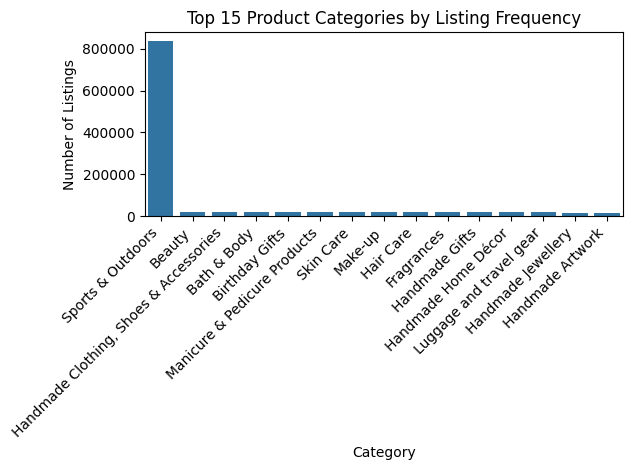

In [20]:
sns.barplot(x=top_categories.index, y=top_categories.values)   
plt.xticks(rotation=45, ha='right')  # Turns the labels 45 degrees
plt.title('Top 15 Product Categories by Listing Frequency')
plt.xlabel('Category')
plt.ylabel('Number of Listings')
plt.tight_layout() # adjusts the margins
plt.show()

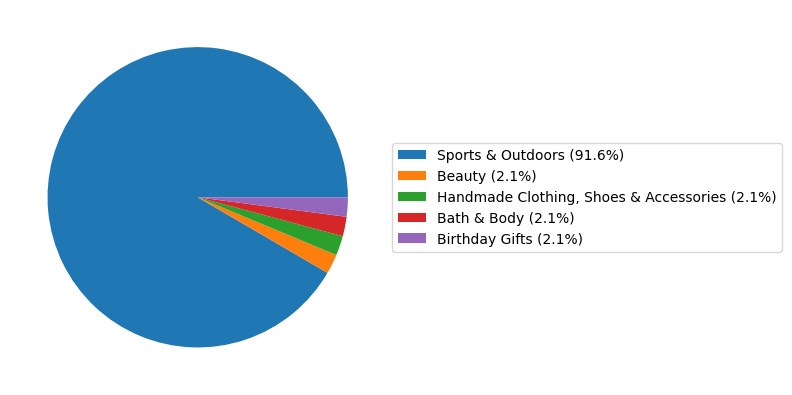

In [32]:
#For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

import matplotlib.pyplot as plt

# Filter the top 5 categories
top_5 = freq_table.head(5)

# Create the graphic

top_5 = freq_table.head(5)
total = top_5.sum()

# Create custom labels: "Name (Percentage)"
labels = [f"{name} ({val/total*100:.1f}%)" for name, val in top_5.items()]

# Plot clean pie (no text inside or outside)
ax = top_5.plot(kind='pie', figsize=(8, 8), autopct=None, labeldistance=None)

# Show ONLY the custom legend
plt.legend(labels, loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
The category Sports & Outdoors dominates the listing.

In [ ]:
#Part 2: Delving into Product Pricing

#Business Question: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

#1. Measures of Centrality:

#Calculate the mean, median, and mode for the price of products.
#What's the average price point of products listed? How does this compare with the most common price point (mode)?

In [35]:
print(df.columns)   

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='str')


In [37]:
col = 'price' 

mean_val = df[col].mean()
median_val = df[col].median()
mode_val = df[col].mode()[0] # .mode() returns a list, so we take the first item

print(f"Mean: {mean_val}")
print(f"Median: {median_val}")
print(f"Mode: {mode_val}")   

Mean: 89.24380943923661
Median: 19.09
Mode: 9.99


In [ ]:
#The average price point is £89.24, which is nearly 9 times higher than the most common price point (mode) of £9.99. 
#This large discrepancy indicates the data is heavily skewed by a few very expensive products, 
#making the mode a more accurate representation of a "typical" item's cost than the average.

In [ ]:
#2. Measures of Dispersion:
#Determine the variance, standard deviation, range, and interquartile range for product price.
#How varied are the product prices? Are there any indicators of a significant spread in prices?

In [39]:
col = 'price' 

variance = df[col].var()
std_dev = df[col].std()
data_range = df[col].max() - df[col].min()
iqr = df[col].quantile(0.75) - df[col].quantile(0.25)

print(f"Variance: {variance:.2f}")
print(f"Standard Deviation: {std_dev:.2f}")
print(f"Range: {data_range:.2f}")
print(f"Interquartile Range (IQR): {iqr:.2f}")   

Variance: 119445.49
Standard Deviation: 345.61
Range: 100000.00
Interquartile Range (IQR): 36.00


In [ ]:
#How varied are the product prices? Are there any indicators of a significant spread in prices?

#Yes, there are extremely strong indicators of a significant spread in prices, 
#characterized by a massive disparity between the overall range and the core data cluster:

#Huge Overall Spread: The Range of 100,000.00 and a high Standard Deviation of 345.61 (relative to the mean ~89) indicate that prices vary wildly, 
#stretching from very cheap items to extremely expensive outliers. 

#Tight Core Cluster: In sharp contrast, the Interquartile Range (IQR) is only 36.00.  
#This reveals that the middle 50% of all products are actually priced within a narrow £36 window.

#Conclusion: The data is heavily skewed by outliers.  
#While the "typical" product price is quite consistent (tight IQR), a few exceptionally expensive products are inflating the total 
#Range and Standard Deviation, creating the illusion of uniform variability when most products are actually similarly priced.

<Axes: xlabel='price', ylabel='Count'>

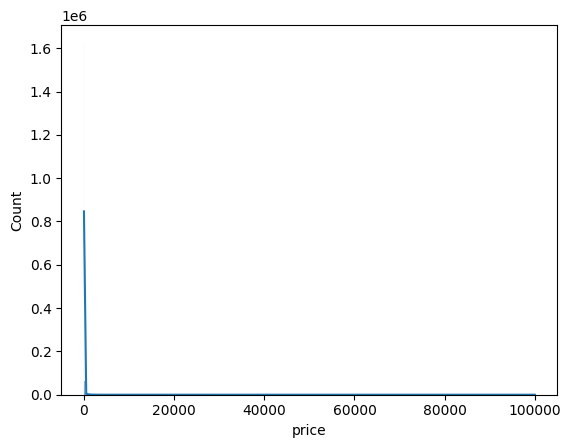

In [41]:
#3. Visualizations:

#Is there a specific price range where most products fall? 
#Plot a histogram to visualize the distribution of product prices. 

#If its hard to read these diagrams, think why this is, and explain how it could be solved..

sns.histplot(df["price"], kde = True)

In [ ]:
#The histogram is unreadable because of extreme right-skewness in the data.

#Why it looks like a single spike:

#Massive Outliers: As seen in the previous statistics, the price Range is 100,000, but the median is only £19.09.

#Scale Distortion: The few extremely expensive products (up to £100k) force the X-axis to stretch very wide. 
#This squashes the vast majority of products (which are cheap, under £100) into a tiny sliver on the far left.

#How to solve it: We need to filter the data to exclude the extreme outliers before plotting. 
#This allows the histogram to "zoom in" on the price range where most products actually exist.

In [ ]:
#Extreme Concentration at Low Prices: The vast majority of products are clustered in the £0–£25 range, with the tallest bar reaching nearly 350,000 
#listings. This confirms that the "typical" product on this platform is very cheap.

#Rapid Drop-off: As the price increases beyond £25, the frequency of listings drops sharply. The long, flat tail extending to £200 shows that 
#while mid-priced items exist, they are significantly less common than the cheapest items.

#Validation of Previous Stats: This visual perfectly explains why the mean (£89) was so much higher than the mode (£9.99). 
#Even within this "zoomed-in" view of under £200, the distribution is heavily right-skewed, proving that the market is dominated by low-cost items 
#with progressively fewer options as prices rise.

#This confirms that £200 was a good choice for a cutoff: it removed the massive £100,000 outliers while revealing the true shape of the market, 
#which is otherwise invisible on a full-scale chart.

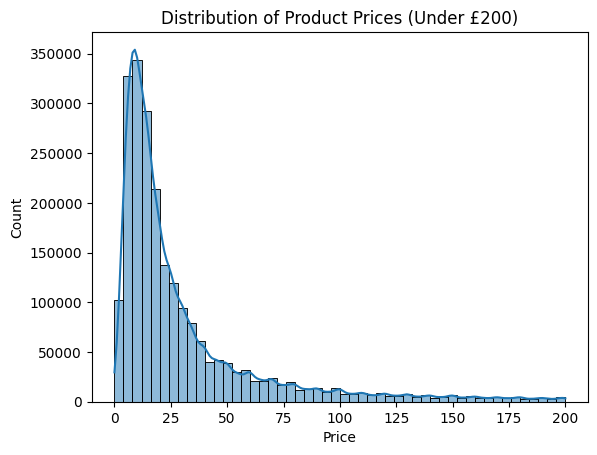

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter: Keep only products with price < 200 
# This removes the extreme outliers that stretch the axis
df_zoomed = df[df['price'] < 200]

# Plot the filtered data
sns.histplot(df_zoomed['price'], kde=True, bins=50)

plt.title('Distribution of Product Prices (Under £200)')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()   

In [ ]:
#Are there products that are priced significantly higher than the rest? 
#Use a box plot to showcase the spread and potential outliers in product pricing.

<Axes: ylabel='price'>

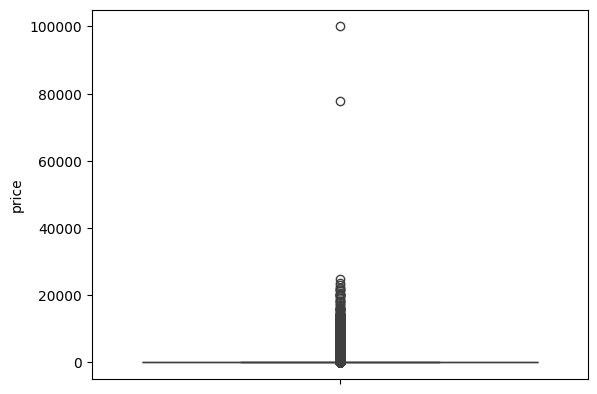

In [45]:
sns.boxplot(data = df["price"])

In [ ]:
#Yes, there are products priced significantly higher than the rest.

#The chart clearly identifies two distinct outliers (represented by the circles at the top) with prices around £80,000 and £100,000. 
#In contrast, the vast majority of the data is compressed into the bottom section of the plot (the box and whiskers), 
#indicating that typical prices are extremely low (likely under £50, as seen in the previous histogram).

#This visual confirms the earlier statistics: the Range of £100,000 is driven entirely by these few extreme items, 
#while the core market remains very cheap. 

#The box plot is the ideal tool for this because it separates these anomalies from the main distribution, making them impossible to miss.

In [ ]:
#Part 3: Unpacking Product Ratings
#Business Question: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

#1. Measures of Centrality:

#Calculate the mean, median, and mode for the rating of products.
#How do customers generally rate products? Is there a common trend?

In [46]:
print(df.columns)   

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='str')


In [51]:
df['stars']

0          4.7
1          4.7
2          4.7
3          4.7
4          4.6
          ... 
2443646    0.0
2443647    0.0
2443648    0.0
2443649    4.3
2443650    4.5
Name: stars, Length: 2443651, dtype: float64

In [52]:
col2 = 'stars' 

mean_val = df[col2].mean()
median_val = df[col2].median()
mode_val = df[col2].mode()[0] # .mode() returns a list, so we take the first item

print(f"Mean: {mean_val}")
print(f"Median: {median_val}")
print(f"Mode: {mode_val}")   

Mean: 2.152836472966066
Median: 0.0
Mode: 0.0


In [ ]:
#The product rating data reveals that the most common scenario is having no ratings at all, 
#with both the median and mode being 0.0. This suggests that over half of the products in the dataset are likely new or unpopular items 
#that have not yet received customer reviews. 

#Consequently, the low mean of 2.15 is skewed by these zeros, and a true assessment of customer satisfaction requires analyzing 
#only the subset of products with actual ratings greater than zero.

In [ ]:
#2. Measures of Dispersion:

#Determine the variance, standard deviation, and interquartile range for product rating.
#Are the ratings consistent, or is there a wide variation in customer feedback?

In [53]:
col2 = 'stars' 

variance = df[col2].var()
std_dev = df[col2].std()
data_range = df[col2].max() - df[col2].min()
iqr = df[col2].quantile(0.75) - df[col2].quantile(0.25)

print(f"Variance: {variance:.2f}")
print(f"Standard Deviation: {std_dev:.2f}")
print(f"Range: {data_range:.2f}")
print(f"Interquartile Range (IQR): {iqr:.2f}")   

Variance: 4.82
Standard Deviation: 2.19
Range: 5.00
Interquartile Range (IQR): 4.40


In [ ]:
#The ratings show extreme inconsistency and wide variation, indicating a polarized dataset rather than a consistent trend.

#Massive Spread: On a scale of only 0 to 5, a Standard Deviation of 2.19 is huge, meaning ratings typically swing wildly from the average.

#Two Extremes: The IQR of 4.40 (nearly the full range) confirms the data is split between 0.0 (unrated products) and high scores, 
#with very few products in the middle.

#The Variance (4.82) and Range (5.00) confirm that customer feedback is maximally inconsistent and deeply polarized. 

#Conclusion: Customer feedback is not uniform; it is dominated by products with no reviews and a smaller group of highly-rated items.

In [ ]:
#3. Shape of the Distribution:

#Calculate the skewness and kurtosis for the rating column.
#Are the ratings normally distributed, or do they lean towards higher or lower values?

In [54]:
df["stars"].skew()

np.float64(0.08120735761080881)

In [55]:
df["stars"].kurtosis()

np.float64(-1.9260061280432994)

In [ ]:
#The near-zero skewness (0.08) indicates the ratings are symmetrically distributed without a strong lean toward high or low values. 

#However, the strongly negative kurtosis (-1.93) confirms the data is not normally distributed; instead, it forms a flat, broad shape 
#with fewer central clusters than a bell curve. This reflects the earlier findings of a polarized dataset where ratings are spread evenly 
#across the scale rather than clustering around an average.

<Axes: xlabel='stars', ylabel='Count'>

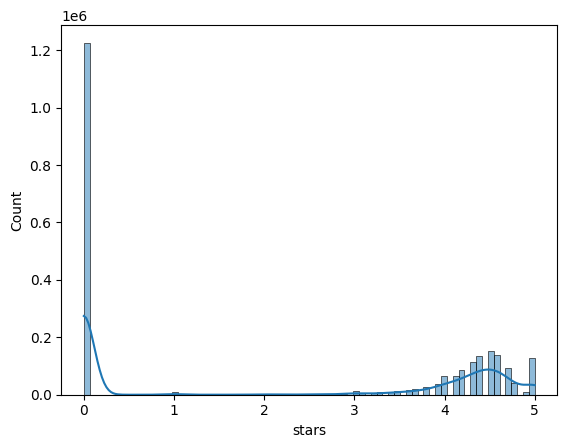

In [58]:
#4. Visualizations:

#Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

sns.histplot(df["stars"], kde = True)

In [ ]:
#Is there a specific rating that is more common?

#Yes, overwhelmingly. The rating of 0 stars is by far the most common.

#Massive Spike at 0: The histogram shows a gigantic bar at the 0 mark on the x-axis, reaching a count of over 1.2 million 
#(indicated by the 1e6 scale on the y-axis).

#Near-Zero Counts Elsewhere: For ratings between 1 and 3, the counts are barely visible, appearing almost flat against the axis.

#Small Secondary Cluster: There is a small, visible increase in counts between 4 and 5 stars, but it is tiny compared to the massive volume of 0-star ratings.

#Conclusion: The data indicates that the vast majority of products in this dataset are unrated (represented as 0). 
#While there is a small segment of highly-rated products (4–5 stars), the "typical" product in this specific dataset has no rating at all. 
#This confirms your previous statistical findings where the mode and median were both 0.0.

In [ ]:
#Submission: Submit a Jupyter Notebook which contains code and a business-centric report summarizing your findings.

In [ ]:
#Business-centric report:

#The dataset is heavily dominated by the "Sports & Outdoors" category, which accounts for over 90% of all listings, 
#while the remaining 295 categories are negligible in comparison. 

#Product prices are extremely right-skewed: while the mean is inflated to £89.24 by rare outliers (up to £100,000), the typical product is very cheap,
#with a mode of £9.99, a median of £19.09, and a tight interquartile range of £36. 

#Visualizations confirm that nearly all products cost under £200, with the massive range driven entirely by a few expensive anomalies. 

#Regarding customer feedback, the data is polarized and bimodal: the majority of products have a rating of 0 (likely unrated), 
#creating a flat distribution with no central "bell curve" peak. Consequently, the mean rating (2.15) is misleading, as the market consists 
#mostly of unrated items and a smaller subset of highly-rated ones, with very few average reviews.